# fastText 품질 분류기

fastText를 사용해 텍스트 품질을 분류하는 모델을 만듭니다.
- **긍정 예시**: 위키백과 (고품질 텍스트)
- **부정 예시**: C4 원본 (정제되지 않은 텍스트)
- **테스트**: C4 realnewslike 하위집합

## 1. 환경 설정

In [19]:
# 필요한 패키지 설치
!pip install fasttext datasets tqdm scikit-learn

In [20]:
import fasttext
import os
import random
import re
from pathlib import Path
from tqdm import tqdm
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix

random.seed(42)
DATA_DIR = Path("fasttext_data")
DATA_DIR.mkdir(exist_ok=True)
print("환경 설정 완료")

환경 설정 완료


## 2. 텍스트 전처리

In [21]:
def preprocess(text: str) -> str:
    """fastText 학습용 텍스트 전처리"""
    # 줄바꿈을 공백으로 변환
    text = text.replace("\n", " ").replace("\r", " ")
    # 연속 공백 제거
    text = re.sub(r"\s+", " ", text)
    return text.strip().lower()

def write_fasttext_lines(file_path: Path, texts: list[str], label: str) -> None:
    """fastText 형식으로 파일에 쓰기: __label__<label> <text>"""
    with open(file_path, "a", encoding="utf-8") as f:
        for text in texts:
            cleaned = preprocess(text)
            if len(cleaned) > 20:  # 너무 짧은 텍스트 제외
                f.write(f"__label__{label} {cleaned}\n")

## 3. 데이터 수집

### 3-1. 긍정 예시: 위키백과

In [22]:
N_SAMPLES = 50_000  # 클래스당 샘플 수

print("위키백과 데이터 로딩 중...")
wiki_dataset = load_dataset(
    "wikimedia/wikipedia",
    "20231101.en",
    split="train",
    streaming=True,
    trust_remote_code=True,
)

wiki_texts = []
for item in tqdm(wiki_dataset, total=N_SAMPLES, desc="Wikipedia"):
    wiki_texts.append(item["text"])  # 앞 2000자만 사용
    if len(wiki_texts) >= N_SAMPLES:
        break

print(f"위키백과 샘플 수: {len(wiki_texts):,}")
print(f"예시: {wiki_texts[0][:200]}")

위키백과 데이터 로딩 중...


Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Wikipedia: 100%|█████████▉| 49999/50000 [00:15<00:00, 3126.22it/s]

위키백과 샘플 수: 50,000
예시: Anarchism is a political philosophy and movement that is skeptical of all justifications for authority and seeks to abolish the institutions it claims maintain unnecessary coercion and hierarchy, typi


### 3-2. 부정 예시: C4 원본 (정제되지 않은 버전)

In [23]:
print("C4 원본 데이터 로딩 중...")
c4_raw = load_dataset(
    "allenai/c4",
    "en",
    split="train",
    streaming=True,
    trust_remote_code=True,
)

c4_raw_texts = []
for item in tqdm(c4_raw, total=N_SAMPLES, desc="C4 raw"):
    c4_raw_texts.append(item["text"])
    if len(c4_raw_texts) >= N_SAMPLES:
        break

print(f"C4 원본 샘플 수: {len(c4_raw_texts):,}")
print(f"예시: {c4_raw_texts[0][:200]}")

C4 원본 데이터 로딩 중...


Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

C4 raw: 100%|█████████▉| 49999/50000 [00:07<00:00, 6672.97it/s] 

C4 원본 샘플 수: 50,000
예시: Beginners BBQ Class Taking Place in Missoula!
Do you want to get better at making delicious BBQ? You will have the opportunity, put this on your calendar now. Thursday, September 22nd join World Class


## 4. 학습/검증 데이터 파일 생성

In [24]:
# 학습 80% / 검증 20% 분리
def split_data(texts: list[str], ratio: float = 0.8):
    random.shuffle(texts)
    split = int(len(texts) * ratio)
    return texts[:split], texts[split:]

wiki_train, wiki_val = split_data(wiki_texts)
c4_train, c4_val = split_data(c4_raw_texts)

train_path = DATA_DIR / "train.txt"
val_path = DATA_DIR / "val.txt"

# 기존 파일 삭제 후 재생성
for p in [train_path, val_path]:
    p.unlink(missing_ok=True)

# 긍정(wikipedia) → label: hq (high quality)
# 부정(c4_raw)     → label: lq (low quality)
write_fasttext_lines(train_path, wiki_train, "hq")
write_fasttext_lines(train_path, c4_train, "lq")
write_fasttext_lines(val_path, wiki_val, "hq")
write_fasttext_lines(val_path, c4_val, "lq")

# 학습 데이터 셔플 (클래스가 섞이도록)
with open(train_path, encoding="utf-8") as f:
    lines = f.readlines()
random.shuffle(lines)
with open(train_path, "w", encoding="utf-8") as f:
    f.writelines(lines)

print(f"학습 데이터: {len(lines):,}줄")
with open(val_path, encoding="utf-8") as f:
    val_lines = f.readlines()
print(f"검증 데이터: {len(val_lines):,}줄")

학습 데이터: 79,978줄
검증 데이터: 19,995줄


## 5. fastText 모델 학습

In [25]:
model_path = str(DATA_DIR / "quality_classifier")

print("fastText 모델 학습 중...")
model = fasttext.train_supervised(
    input=str(train_path),
    epoch=5,
    lr=0.5,
    wordNgrams=2,      # 바이그램 사용 (품질 분류에 효과적)
    dim=100,
    loss="softmax",
    thread=4,
    verbose=2,
)

model.save_model(model_path + ".bin")
print(f"모델 저장 완료: {model_path}.bin")

fastText 모델 학습 중...


Read 47M words
Number of words:  1695545
Number of labels: 2


모델 저장 완료: fasttext_data/quality_classifier.bin


Progress: 100.0% words/sec/thread: 2248144 lr:  0.000000 avg.loss:  0.035250 ETA:   0h 0m 0s


## 6. 검증 데이터 평가

In [26]:
# fastText 내장 평가
n_val, precision, recall = model.test(str(val_path))
print(f"검증 샘플 수: {n_val:,}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {2 * precision * recall / (precision + recall):.4f}")

검증 샘플 수: 19,995
Precision: 0.9893
Recall:    0.9893
F1:        0.9893


In [27]:
# 클래스별 상세 평가
y_true, y_pred = [], []
with open(val_path, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        # 레이블 파싱: __label__hq text...
        parts = line.split(" ", 1)
        true_label = parts[0].replace("__label__", "")
        text = parts[1] if len(parts) > 1 else ""
        pred_labels, _ = model.predict(text)
        pred_label = pred_labels[0].replace("__label__", "")
        y_true.append(true_label)
        y_pred.append(pred_label)

print(classification_report(y_true, y_pred, target_names=["hq (Wikipedia)", "lq (C4 raw)"]))
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred, labels=["hq", "lq"]))

                precision    recall  f1-score   support

hq (Wikipedia)       0.99      0.99      0.99      9995
   lq (C4 raw)       0.99      0.99      0.99     10000

      accuracy                           0.99     19995
     macro avg       0.99      0.99      0.99     19995
  weighted avg       0.99      0.99      0.99     19995

Confusion Matrix:
[[9897   98]
 [ 115 9885]]


## 7. C4 realnewslike 하위집합 적용

C4 realnewslike는 뉴스 사이트에서 수집된 고품질 필터링 데이터입니다.  
분류기가 이를 `hq`로 판별하는지 확인합니다.

In [28]:
print("C4 realnewslike 데이터 로딩 중...")
c4_news = load_dataset(
    "allenai/c4",
    "realnewslike",
    split="train",
    streaming=True,
    trust_remote_code=True,
)

N_TEST = 5_000
news_texts = []
for item in tqdm(c4_news, total=N_TEST, desc="C4 realnewslike"):
    news_texts.append(item["text"])
    if len(news_texts) >= N_TEST:
        break

print(f"realnewslike 샘플 수: {len(news_texts):,}")

C4 realnewslike 데이터 로딩 중...


Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/512 [00:00<?, ?it/s]

C4 realnewslike: 100%|█████████▉| 4999/5000 [00:01<00:00, 3266.20it/s]

realnewslike 샘플 수: 5,000


In [29]:
# 분류기 적용
results = {"hq": 0, "lq": 0}
scores_hq = []

for text in tqdm(news_texts, desc="분류 중"):
    cleaned = preprocess(text)
    if not cleaned:
        continue
    labels, probs = model.predict(cleaned, k=2)
    label_prob = dict(zip(
        [l.replace("__label__", "") for l in labels],
        probs
    ))
    pred = max(label_prob, key=label_prob.get)
    results[pred] += 1
    scores_hq.append(label_prob.get("hq", 0.0))

total = sum(results.values())
print("\n=== C4 realnewslike 분류 결과 ===")
print(f"hq (고품질): {results['hq']:,} ({results['hq']/total*100:.1f}%)")
print(f"lq (저품질): {results['lq']:,} ({results['lq']/total*100:.1f}%)")
print(f"\n평균 hq 확률 점수: {sum(scores_hq)/len(scores_hq):.4f}")

분류 중: 100%|██████████| 5000/5000 [00:01<00:00, 2593.45it/s]


=== C4 realnewslike 분류 결과 ===
hq (고품질): 30 (0.6%)
lq (저품질): 4,970 (99.4%)

평균 hq 확률 점수: 0.0139


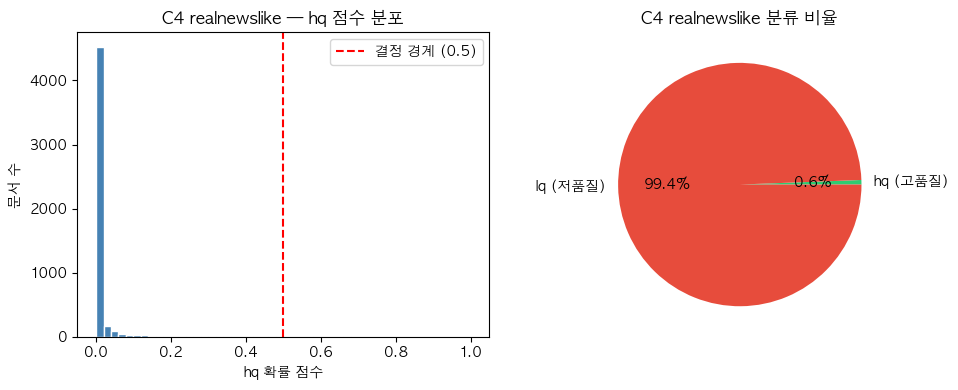

In [30]:
import matplotlib.pyplot as plt

# 한글 폰트 설정 (macOS)
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(10, 4))

# hq 확률 분포
plt.subplot(1, 2, 1)
plt.hist(scores_hq, bins=50, color="steelblue", edgecolor="white")
plt.xlabel("hq 확률 점수")
plt.ylabel("문서 수")
plt.title("C4 realnewslike — hq 점수 분포")
plt.axvline(0.5, color="red", linestyle="--", label="결정 경계 (0.5)")
plt.legend()

# 클래스 비율 파이차트
plt.subplot(1, 2, 2)
plt.pie(
    [results["hq"], results["lq"]],
    labels=["hq (고품질)", "lq (저품질)"],
    autopct="%1.1f%%",
    colors=["#2ecc71", "#e74c3c"],
)
plt.title("C4 realnewslike 분류 비율")

plt.tight_layout()
plt.savefig(DATA_DIR / "classification_results.png", dpi=150)
plt.show()

## 8. 분류기 동작 확인: 예시 문서 분석

In [31]:
def classify(text: str) -> dict:
    cleaned = preprocess(text)
    labels, probs = model.predict(cleaned, k=2)
    return {
        l.replace("__label__", ""): round(float(p), 4)
        for l, p in zip(labels, probs)
    }

# 긍정 예시: 위키백과 스타일 문장
wiki_example = """The Python programming language was created by Guido van Rossum 
and first released in 1991. It emphasizes code readability and supports multiple 
programming paradigms including structured, object-oriented, and functional programming."""

# 부정 예시: 스팸/저품질 텍스트
spam_example = """Click here now!!! Best deals on shoes bags watches FREE SHIPPING 
LIMITED TIME OFFER buy 2 get 1 free don't miss out subscribe today!!!"""

# realnewslike 첫 번째 문서
news_example = news_texts[0]

print("[위키백과 스타일]")
print(f"텍스트: {wiki_example[:100]}...")
print(f"결과: {classify(wiki_example)}\n")

print("[저품질/스팸 텍스트]")
print(f"텍스트: {spam_example[:100]}...")
print(f"결과: {classify(spam_example)}\n")

print("[C4 realnewslike 첫 번째 문서]")
print(f"텍스트: {news_example[:150]}...")
print(f"결과: {classify(news_example)}")

[위키백과 스타일]
텍스트: The Python programming language was created by Guido van Rossum 
and first released in 1991. It emph...
결과: {'lq': 1.0, 'hq': 0.0}

[저품질/스팸 텍스트]
텍스트: Click here now!!! Best deals on shoes bags watches FREE SHIPPING 
LIMITED TIME OFFER buy 2 get 1 fre...
결과: {'lq': 1.0, 'hq': 0.0}

[C4 realnewslike 첫 번째 문서]
텍스트: After the martyrdom of St. Boniface, Vergilius was made Bishop of Salzburg (766 or 767) and laboured successfully for the upbuilding of his diocese as...
결과: {'lq': 0.9992, 'hq': 0.0008}


In [32]:
# realnewslike 상위 5개 고품질 문서
print("=== realnewslike 중 hq 점수 상위 5개 문서 ===")
news_with_scores = [
    (text, classify(text).get("hq", 0))
    for text in news_texts[:500]
]
news_with_scores.sort(key=lambda x: x[1], reverse=True)

for i, (text, score) in enumerate(news_with_scores[:5], 1):
    print(f"\n[{i}] hq 점수: {score:.4f}")
    print(text[:200] + "...")

print("\n=== realnewslike 중 hq 점수 하위 5개 문서 ===")
for i, (text, score) in enumerate(news_with_scores[-5:], 1):
    print(f"\n[{i}] hq 점수: {score:.4f}")
    print(text[:200] + "...")

=== realnewslike 중 hq 점수 상위 5개 문서 ===

[1] hq 점수: 0.5886
Initiated by Joint Chiefs of Staff Chairman General Nathan Twining and Chief of Naval Operations Admiral Arleigh Burke, and then presided over by General Thomas Power, Director of the Joint Strategic ...

[2] hq 점수: 0.4948
On Tuesday, August 20, a US army veteran named Mark Paslawsky was killed during a battle in Ilovyask, near Donetsk, which is currently held by anti-Kiev rebels.
Fighting on the side of pro-government ...

[3] hq 점수: 0.2491
Kathleen, Marchioness of Hartington. Public Domain/U.S. Govt. photo.
On this day in 1948, Kathleen Cavendish, Marchioness of Hartington, the second daughter of Joseph P. Kennedy, Sr., sister of U.S. P...

[4] hq 점수: 0.2132
Trump's new immigration ad was panned as racist. Turns out it was also based on a falsehood. - Hartford Courant Trump's new immigration ad was panned as racist. Turns out it was also based on a falseh...

[5] hq 점수: 0.2002
France is in a difficult position. It has not had a